# Tutorial 8: Three-Model Coupling

Estimated time: 25-45 minutes

## Prerequisites
No extra dependencies beyond base package runtime.

## Learning aims
- Primary package aim: extend the coupling graph to a third model and sample joint outputs across a *chain* `y → C → z → w`.
- Secondary scientific aim: observe how uncertainty propagates **differently** through *deterministic* coupling (it doesn't add) vs *probabilistic* coupling (it accumulates) — and start budgeting noise across coupled cascades.

## Success criteria
- you can compute `std(y)`, `std(z)`, `std(w)` from the samples and explain in one sentence why they differ as they do, with reference to the spec's coupling kinds and σ values.


## Why this tutorial matters

T7 coupled two models: `y` and `C` agreed via a single probabilistic link. Here, three models give you a **chain**: `y → C → z → w`. Open `tutorials/specs/metamodel.three_model.pymc.json` and look at the `couplings` array — the σ values along the chain (`σ=0.2` for `y → C`, deterministic for `C → z`, `σ=0.25` for `z → w`) determine **how much uncertainty accumulates as you walk downstream**.

This is where you start *budgeting noise across a coupled cascade*. The same logic applies to the four real biological models in `projects/tcr_signaling/`: each coupling adds (or doesn't add) width, and by the time you reach the most-downstream variable you should expect a histogram noticeably wider than the upstream prior. The point of this tutorial is to **see that accumulation in numbers**, not just visually.

(Vocabulary recap from T7: `gaussian_link` is probabilistic — Gaussian noise around the transform with width σ. `deterministic` is the hard constraint — `target = transform(source)` exactly, no noise. The two compile to entirely different sampling behaviors.)


## Step 1: Build and sample 3-model metamodel


In [1]:
# Cross-platform setup (Windows / macOS / Linux) — no shell, no PYTHONPATH prefix.
# Find the repo root so `src/` is importable, then load the shared tutorial helpers.
import sys
from pathlib import Path

_root = Path.cwd().resolve()
while not (_root / "src" / "bayesian_metamodeling").is_dir() and _root != _root.parent:
    _root = _root.parent
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

from bayesian_metamodeling.tutorial import bootstrap, run_mm_cli, run_tool

root = bootstrap()  # chdir to repo root + ensure src/ on sys.path (idempotent)
ROOT = root
print("Repo root:", root)


Repo root: /Users/barakraveh/Git/metamodeler_codex_scaffold_docs


In [2]:
run_mm_cli('meta', 'build', 'tutorials/specs/metamodel.three_model.pymc.json')
run_mm_cli('meta', 'sample', 'tutorials/specs/metamodel.three_model.pymc.json', '--draws', '200', '--tune', '100', '--chains', '2', '--seed', '321')


$ bayesmm meta build tutorials/specs/metamodel.three_model.pymc.json
Metamodel IR artifact stored: artifact_id=b2f30204fee943f38f7441a38c525cea ir_path=tmp/metamodel_ir/b2f30204fee943f38f7441a38c525cea/ir.json
$ bayesmm meta sample tutorials/specs/metamodel.three_model.pymc.json --draws 200 --tune 100 --chains 2 --seed 321
Metamodel sample stored: sample_id=0c98ddf18d1f4b7eb8a880066d0e7455 dataset=tmp/metamodel_samples/0c98ddf18d1f4b7eb8a880066d0e7455/samples_dataset.json


0

**Predict before you sample.** You have these starting conditions:

- Prior on `y`: roughly `Normal(0, 1)` (set in the spec).
- `y → C` via `gaussian_link σ=0.2` → `C ≈ y + Normal(0, 0.2)`.
- `C → z` via `deterministic` affine `α=1, β=0` → `z = C` exactly. **No new noise.**
- `z → w` via `gaussian_link σ=0.25` → `w ≈ z + Normal(0, 0.25)`.

Predict, before running anything below: which of `y`, `z`, `w` will have the widest histogram? Which the narrowest? Quantitative version: `std(y) ≈ 1.0` (from the prior). What do you expect for `std(z)` and `std(w)` if noises add in quadrature for independent random variables?


## Step 2: Compare uncertainty spread (graphic)


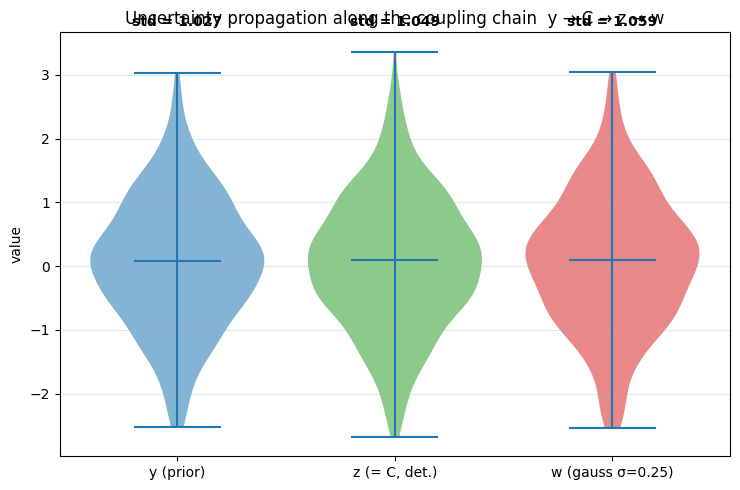


Numeric noise budget along the chain:
  std(y)  = 1.027   (from the prior, before any coupling adds noise)
  std(z)  = 1.049   (z = C exactly, deterministic, no new noise)
  std(w)  = 1.059   (z + gauss noise σ=0.25; quadrature => sqrt(std(z)^2 + 0.25^2))
  predicted std(w) = sqrt(std(z)^2 + 0.25^2) = 1.079


In [3]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# `root` came from bootstrap() at the top of the notebook.
reg = root / "tmp/metamodel_samples_registry.json"
payload = json.loads(reg.read_text())

# Sort by `created_at` (NOT by UUID-hex which is essentially random).
# Filter to the most recent dataset that actually contains the chain variables {y, z, w}.
candidates = sorted(
    [(meta.get("created_at", ""), sid, meta) for sid, meta in payload.items()],
    reverse=True,
)
chosen = None
for created, sid, meta in candidates:
    ds_candidate = Path(meta["samples_dataset_path"])
    if not ds_candidate.is_absolute():
        ds_candidate = root / ds_candidate
    if not ds_candidate.exists():
        continue
    ds_check = json.loads(ds_candidate.read_text())
    if all(name in ds_check["variables"] for name in ("y", "z", "w")):
        chosen = (sid, ds_candidate)
        break
if chosen is None:
    raise RuntimeError(
        "No metamodel sample dataset with variables {y, z, w} found. "
        "Run Step 1 above first (the three-model meta build + sample)."
    )
latest_id, dataset_path = chosen
ds = json.loads(dataset_path.read_text())
vars_ = ds["variables"]

# Flatten chains × draws into 1D arrays per variable.
y = np.asarray(vars_["y"], dtype=float).reshape(-1)
z = np.asarray(vars_["z"], dtype=float).reshape(-1)
w = np.asarray(vars_["w"], dtype=float).reshape(-1)

stats = {
    "y (prior)":    (y, "tab:blue"),
    "z (= C, det.)": (z, "tab:green"),
    "w (gauss σ=0.25)": (w, "tab:red"),
}

# Violin plot: explicit width comparison rather than overlapping translucent histograms.
fig, ax = plt.subplots(figsize=(7.5, 5))
data = [arr for arr, _ in stats.values()]
labels = list(stats.keys())
parts = ax.violinplot(data, showmeans=False, showmedians=True, widths=0.8)
for body, (_, color) in zip(parts["bodies"], stats.values()):
    body.set_facecolor(color)
    body.set_alpha(0.55)

# Annotate std above each violin so the accumulation is explicit, not visual.
y_pos_for_text = max(arr.max() for arr, _ in stats.values()) + 0.4
for i, (arr, _) in enumerate(stats.values(), start=1):
    ax.text(
        i, y_pos_for_text,
        f"std = {arr.std():.3f}",
        ha="center", fontsize=10, fontweight="bold",
    )

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)
ax.set_ylabel("value")
ax.set_title("Uncertainty propagation along the coupling chain  y → C → z → w")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("\nNumeric noise budget along the chain:")
print(f"  std(y)  = {y.std():.3f}   (from the prior, before any coupling adds noise)")
print(f"  std(z)  = {z.std():.3f}   (z = C exactly, deterministic, no new noise)")
print(f"  std(w)  = {w.std():.3f}   (z + gauss noise σ=0.25; quadrature => sqrt(std(z)^2 + 0.25^2))")
print(f"  predicted std(w) = sqrt(std(z)^2 + 0.25^2) = {np.sqrt(z.std()**2 + 0.25**2):.3f}")


## Scientific checkpoint (active learning)

The plot's std annotations make the uncertainty budget explicit. Now interrogate it:

1. **Is `std(w) ≈ sqrt(std(z)² + 0.25²)`?** The printout above does this calculation for you. The two should agree within sampling noise — that's quadrature addition of independent Gaussian noises along the chain.

2. **Predict, then test**: if you doubled σ on the `z → w` link from 0.25 to 0.5, by approximately how much would `std(w)` change? (Hint: it's not exactly double — quadrature again.) Edit `tutorials/specs/metamodel.three_model.pymc.json`, change the second `gaussian_link` σ to 0.5, save, re-run the cells above, compare.

3. **The deterministic surprise**: notice that `std(z) = std(C) ≈ std(y + 0.2 Gaussian)` — the deterministic coupling between C and z added zero new noise. If a chain is mostly `gaussian_link`s with one deterministic link in the middle, the deterministic step is *invisible* in the noise budget. Use this in design: deterministic couplings are free width-wise.

4. **Where the lesson lands for real models**: in `projects/tcr_signaling/`, the four partial models couple via a mix of deterministic and probabilistic links. By the time you've sampled the joint metamodel, the most downstream variable's width is a function of every probabilistic σ along its ancestor chain. Reading off `std` is how you check that the joint inference is well-calibrated.

**Reset both σ values** to their original (0.2 and 0.25) when you're done so the spec matches what later tutorials might reference.
